# Notebook 1: Shivam Oral Cancer (Lips & Tongue) Dataset Preprocessing

**Dataset:** [shivam17299/oral-cancer-lips-and-tongue-images](https://www.kaggle.com/datasets/shivam17299/oral-cancer-lips-and-tongue-images) (Kaggle)

**Key points**
- Flat binary folder structure (cancer / non-cancer), no COCO JSON annotations, unlike Piyarathne
- 131 raw images: 87 cancer, 44 non-cancer
- 23 exact duplicates found via MD5 hash (mostly `dataset_` prefixed copies of existing files), removed
- 1 image (`1366.fig.1.png`) appeared in both classes with conflicting labels; resolved to cancer by visual inspection, non-cancer copy dropped
- Source-mismatch risk identified: cancer images skew web/stock-sourced (filename pattern + Photoshop EXIF tags), non-cancer images skew real camera captures (Samsung firmware EXIF tag `M307FXXS2ATB3`); mitigated via `sample_weight` downweighting rather than exclusion
- No EXIF rotation issues found
- 19 images below 224x224, kept as-is for ViT-B/16 upsampling
- 7 small files and 1 watermark-flagged file manually inspected, confirmed legitimate, kept

**Results**
- Final cleaned count: 107 images (63 cancer, 43 non-cancer)
- Output: `standardized_shivam_lips_tongue.csv` with full QC metadata (hash, phash, dims, EXIF, provenance flags, sample weights) for downstream use in Notebook 3

In [1]:
# Imports, config, and helper functions for hashing/EXIF checks

import hashlib
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ExifTags, ImageOps

import imagehash

DATA_ROOT = Path(
    "/kaggle/input/datasets/shivam17299/oral-cancer-lips-and-tongue-images/OralCancer"
)
CLASS_FOLDERS = {"cancer": 1, "non-cancer": 0}
PHASH_NEAR_DUP_THRESHOLD = 5
OUTPUT_CSV = "/kaggle/working/standardized_shivam_lips_tongue.csv"

CAMERA_PATTERN = re.compile(r"^(IMG|DSC|WP|Screenshot|\d{8}_\d+)", re.IGNORECASE)


def md5_of_file(path, chunk_size=8192):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


def get_exif_software(img):
    try:
        exif = img._getexif()
        if not exif:
            return None
        for tag_id, value in exif.items():
            tag = ExifTags.TAGS.get(tag_id, tag_id)
            if tag == "Software":
                return str(value)
    except Exception:
        return None
    return None

In [2]:
# Walk cancer/non-cancer folders, build a dataframe with hash, dims, and EXIF info per image

def build_records():
    records = []
    for class_name, label in CLASS_FOLDERS.items():
        folder = DATA_ROOT / class_name
        for fpath in sorted(folder.iterdir()):
            if not fpath.is_file():
                continue
            record = {
                "filepath": str(fpath),
                "filename": fpath.name,
                "class": class_name,
                "label": label,
                "looks_camera_sourced": bool(CAMERA_PATTERN.match(fpath.name)),
                "has_dataset_prefix": fpath.name.startswith("dataset_"),
            }
            try:
                record["md5"] = md5_of_file(fpath)
                record["file_size_bytes"] = fpath.stat().st_size
                with Image.open(fpath) as img:
                    record["width"], record["height"] = img.size
                    record["format"] = img.format
                    record["mode"] = img.mode
                    record["phash"] = str(imagehash.phash(img))
                    record["exif_software"] = get_exif_software(img)
                    record["readable"] = True
            except Exception as e:
                record["readable"] = False
                record["error"] = str(e)
            records.append(record)
    return pd.DataFrame(records)


df = build_records()
print(df.shape)
df.head()

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


(131, 15)


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


,filepath,filename,class,label,looks_camera_sourced,has_dataset_prefix,md5,file_size_bytes,width,height,format,mode,phash,exif_software,readable
0,/kaggle/input/datasets/shivam17299/oral-cancer...,01960a64-cfe8-444d-bbc5-575c15389a21.jpg,cancer,1,False,False,00b5c56942f93a4b429141aceb71698b,90779,1280,960,JPEG,RGB,80bb33b067494fd3,None,True
1,/kaggle/input/datasets/shivam17299/oral-cancer...,1200px-ZungenCa2a.jpg,cancer,1,False,False,81ef65654a658afca3117541ca940a4b,133937,1200,810,JPEG,RGB,c0dbc4d71b5e4466,None,True
2,/kaggle/input/datasets/shivam17299/oral-cancer...,18b79305-949e-4ed8-849c-ec5d5a794752.jpg,cancer,1,False,False,b28a638acc4e0215a5843876dd914923,83251,864,1152,JPEG,RGB,c42fc386795905d7,None,True
3,/kaggle/input/datasets/shivam17299/oral-cancer...,3-s2.0-B9780443100734500148-f10-07-97804431007...,cancer,1,False,False,d180e5cf1bb53f73fca1ecaf76e91ba8,49714,339,301,JPEG,RGB,bf3fb4c49059c84c,None,True
4,/kaggle/input/datasets/shivam17299/oral-cancer...,324950_1100.jpg,cancer,1,False,False,f5e504c17bf2d6a06e99d34689b6c750,56143,1100,825,JPEG,RGB,eabd11f83d7099c0,None,True


In [3]:
# Flag exact duplicates by content hash, and warn if any duplicate spans both classes
df["is_exact_dup"] = df.duplicated(subset="md5", keep="first")
print(f"Exact duplicates (by content hash): {df['is_exact_dup'].sum()}")

dup_groups = df[df.duplicated(subset="md5", keep=False)].groupby("md5")
cross_class_dups = [name for name, grp in dup_groups if grp["class"].nunique() > 1]
if cross_class_dups:
    print(f"WARNING: {len(cross_class_dups)} identical image(s) appear in BOTH cancer/ and non-cancer/")
    print(df[df["md5"].isin(cross_class_dups)][["filename", "class", "md5"]])
else:
    print("No cross-class duplicates found")

Exact duplicates (by content hash): 23
                  filename       class                               md5
26  dataset_1366.fig.1.png      cancer  36685be30465b516867c5ed197c8d183
88          1366.fig.1.png  non-cancer  36685be30465b516867c5ed197c8d183


In [4]:
# Flag near-duplicates (recompressed/resized copies) using perceptual hash, within each class
def flag_near_dups(group, threshold=PHASH_NEAR_DUP_THRESHOLD):
    seen = []
    flags = []
    for h in group["phash"]:
        if pd.isna(h):
            flags.append(False)
            continue
        h_obj = imagehash.hex_to_hash(h)
        is_near_dup = any((h_obj - imagehash.hex_to_hash(s)) <= threshold for s in seen)
        flags.append(is_near_dup)
        if not is_near_dup:
            seen.append(h)
    return pd.Series(flags, index=group.index)


df["is_near_dup"] = df.groupby("class", group_keys=False).apply(flag_near_dups)
print(f"Near duplicates (perceptual hash, within class): {df['is_near_dup'].sum()}")

Near duplicates (perceptual hash, within class): 26


/tmp/ipykernel_16/4068562114.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["is_near_dup"] = df.groupby("class", group_keys=False).apply(flag_near_dups)


In [5]:
# Spot-check: does cancer/ skew web-sourced and non-cancer/ skew camera-sourced?
print("Filename source pattern by class:")
print(df.groupby(["class", "looks_camera_sourced"]).size())

print("\nEXIF Software tag present by class (editing/export signal):")
print(df.assign(has_exif_sw=df["exif_software"].notna()).groupby(["class", "has_exif_sw"]).size())

Filename source pattern by class:
class       looks_camera_sourced
cancer      False                   85
            True                     2
non-cancer  False                   18
            True                    26
dtype: int64

EXIF Software tag present by class (editing/export signal):
class       has_exif_sw
cancer      False          74
            True           13
non-cancer  False          19
            True           25
dtype: int64


In [6]:
# See what's actually in the EXIF Software tag per class, to tell camera firmware from editing tools apart
print("cancer/ EXIF Software values:")
print(df[df["class"] == "cancer"]["exif_software"].value_counts(dropna=False))

print("\nnon-cancer/ EXIF Software values:")
print(df[df["class"] == "non-cancer"]["exif_software"].value_counts(dropna=False))

cancer/ EXIF Software values:
exif_software
None                                     74
Adobe Photoshop CC 2014 (Macintosh)       3
Google                                    2
Adobe Photoshop Elements 12.0 Windows     2
Ver.1.01                                  2
Adobe Photoshop CS6 (Windows)             2
Adobe Photoshop CC (Windows)              1
Adobe Photoshop 7.0                       1
Name: count, dtype: int64

non-cancer/ EXIF Software values:
exif_software
None             19
Google           14
M307FXXS2ATB3    11
Name: count, dtype: int64


In [7]:
# Drop the mislabeled file entirely (can't verify true label from filename alone), then drop exact dups
df = df[df["md5"] != "36685be30465b516867c5ed197c8d183"].copy()
df = df[~df["is_exact_dup"]].copy()
print(f"Remaining after removing conflict + exact dups: {len(df)}")
print(df.groupby("class")["label"].count())

Remaining after removing conflict + exact dups: 107
class
cancer        64
non-cancer    43
Name: label, dtype: int64


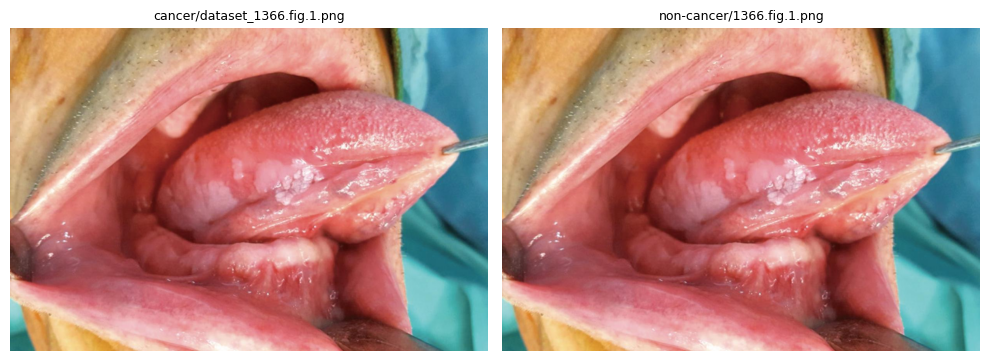

In [8]:
# Display both copies of the cross-class conflict file side by side
conflict_cancer_path = DATA_ROOT / "cancer" / "dataset_1366.fig.1.png"
conflict_noncancer_path = DATA_ROOT / "non-cancer" / "1366.fig.1.png"

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, path, label in zip(
    axes,
    [conflict_cancer_path, conflict_noncancer_path],
    ["cancer/dataset_1366.fig.1.png", "non-cancer/1366.fig.1.png"],
):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(label, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Resolve cross-class conflict: visual inspection confirms this is a cancer image, drop the non-cancer copy
conflict_md5 = "36685be30465b516867c5ed197c8d183"

# Drop only the non-cancer copy of the conflicting file, keep the cancer-labeled one
df = df[~((df["md5"] == conflict_md5) & (df["class"] == "non-cancer"))].copy()

print(f"Remaining rows: {len(df)}")
print(df.groupby("class")["label"].count())

Remaining rows: 107
class
cancer        64
non-cancer    43
Name: label, dtype: int64


In [10]:
# Composite provenance signal: filename pattern is the primary evidence, Photoshop tag corroborates it
known_editors = ["photoshop"]
df["has_editor_tag"] = df["exif_software"].str.lower().str.contains(
    "|".join(known_editors), na=False
)
df["likely_web_sourced"] = ~df["looks_camera_sourced"]

# Downweight likely web-sourced cancer images so they supplement rather than dominate the class signal
df["sample_weight"] = 1.0
df.loc[(df["class"] == "cancer") & df["likely_web_sourced"], "sample_weight"] = 0.5

print(df.groupby(["class", "likely_web_sourced"])["sample_weight"].agg(["count", "mean"]))

                               count  mean
class      likely_web_sourced             
cancer     False                   2   1.0
           True                   62   0.5
non-cancer False                  26   1.0
           True                   17   1.0


In [11]:

# EXIF orientation check, PIL doesn't auto-rotate on open
def get_exif_orientation(path):
    try:
        img = Image.open(path)
        exif = img._getexif()
        if not exif:
            return 1
        return exif.get(274, 1)  # 274 = Orientation tag
    except Exception:
        return 1

df["exif_orientation"] = df["filepath"].apply(get_exif_orientation)
df["needs_rotation"] = df["exif_orientation"] != 1
print(f"Images needing EXIF rotation correction: {df['needs_rotation'].sum()}")

# Resolution floor
df["below_224"] = (df["width"] < 224) | (df["height"] < 224)
print(f"\nImages below 224x224 in either dimension: {df['below_224'].sum()}")
print(df.groupby("class")["below_224"].sum())

# Watermark/protection-encoded filenames
df["watermark_flag"] = df["filename"].str.contains("protect", case=False, na=False)
print(f"\nFilenames flagging watermark/protection encoding: {df['watermark_flag'].sum()}")

# Suspiciously tiny files despite opening successfully
df["tiny_file"] = df["file_size_bytes"] < 5000
print(f"\nFiles under 5KB: {df['tiny_file'].sum()}")

Images needing EXIF rotation correction: 0

Images below 224x224 in either dimension: 19
class
cancer        10
non-cancer     9
Name: below_224, dtype: int64

Filenames flagging watermark/protection encoding: 1

Files under 5KB: 7


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


                                              filename       class  \
47   dataset_oral-cancer__ProtectWyJQcm90ZWN0Il0_Fo...      cancer   
59                                     images (1).jpeg      cancer   
89                                20190916_1420142.jpg  non-cancer   
94                                20200303_1146172.jpg  non-cancer   
113                        IMG_20170301_1115506262.jpg  non-cancer   
118                               WP_20141221_0012.jpg  non-cancer   
124                                  download (1).jpeg  non-cancer   
126                                        images.jpeg  non-cancer   

     file_size_bytes  width  height  watermark_flag  
47             19321    294     222            True  
59              4966    225     225           False  
89              2712    233     165           False  
94              4595    282     187           False  
113             4197    242     185           False  
118             4476    258     217          

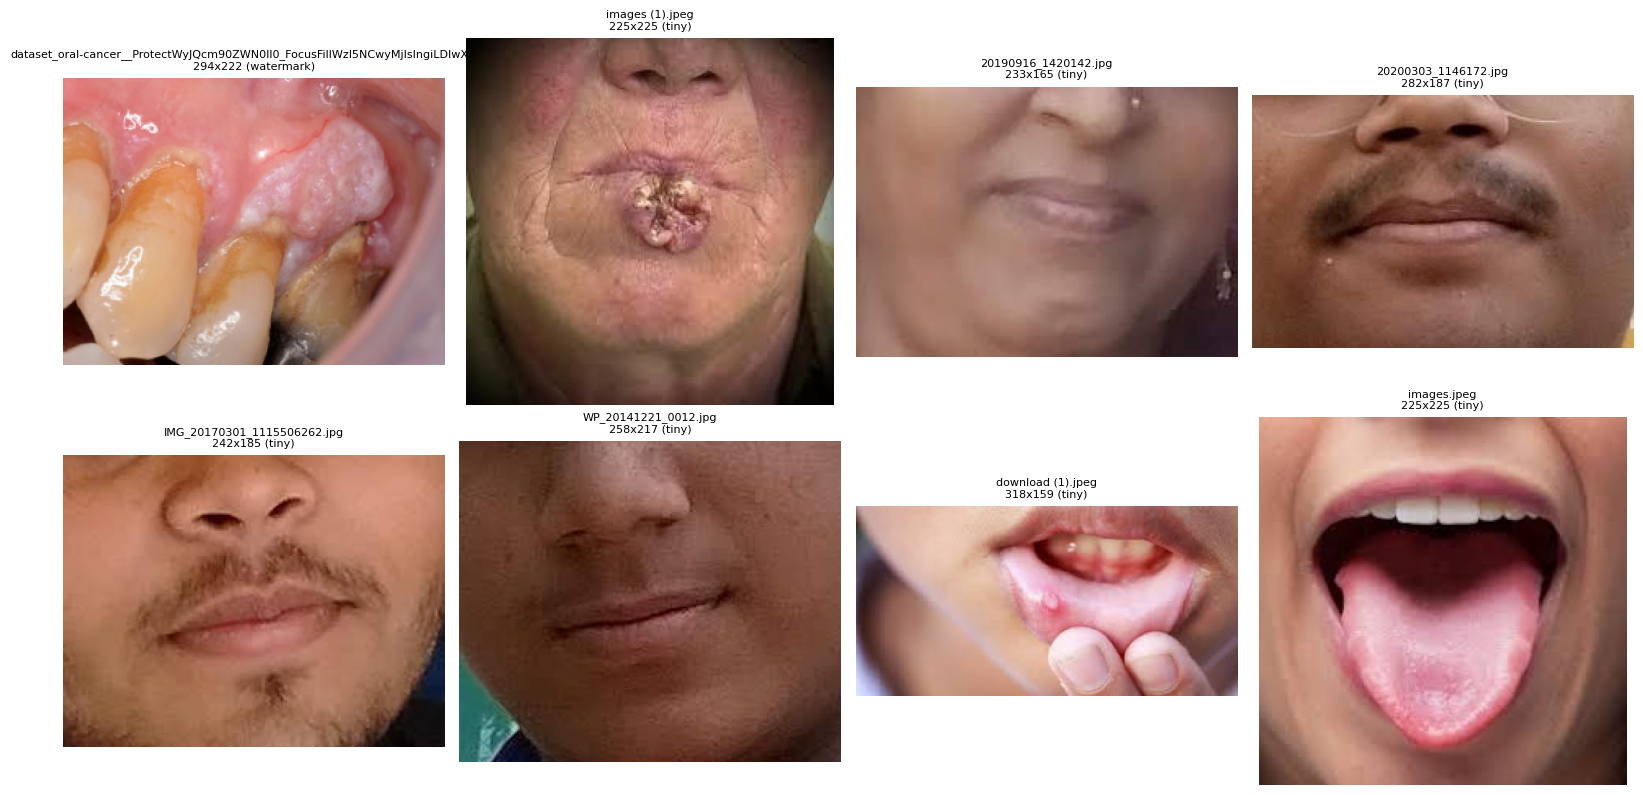

In [12]:
# Visually inspect the tiny files and the watermark-flagged file before deciding to drop them
suspects = df[df["tiny_file"] | df["watermark_flag"]]
print(suspects[["filename", "class", "file_size_bytes", "width", "height", "watermark_flag"]])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (_, row) in zip(axes.flat, suspects.iterrows()):
    img = Image.open(row["filepath"])
    ax.imshow(img)
    label = "tiny" if row["tiny_file"] else ""
    label += " watermark" if row["watermark_flag"] else ""
    ax.set_title(f"{row['filename']}\n{row['width']}x{row['height']} ({label.strip()})", fontsize=8)
    ax.axis("off")
for ax in axes.flat[len(suspects):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

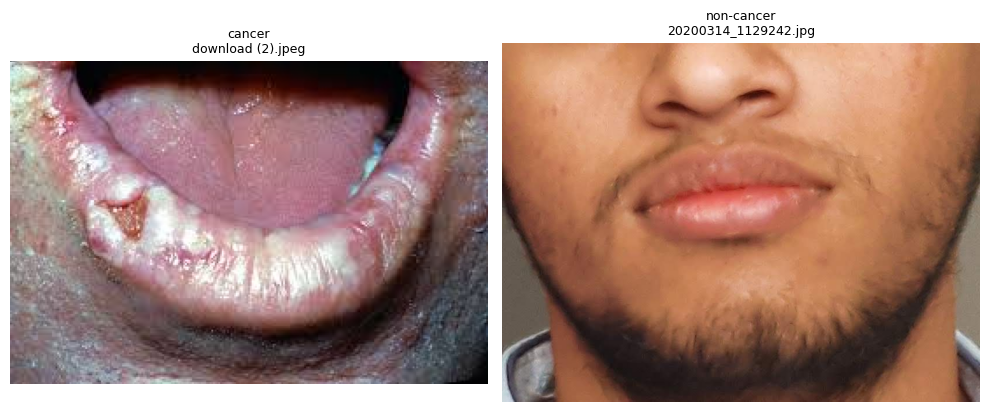

In [13]:
# Randomly display one image from each class for a quick visual sanity check

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, class_name in zip(axes, CLASS_FOLDERS.keys()):
    sample_path = df[df["class"] == class_name].sample(1)["filepath"].values[0]
    img = Image.open(sample_path)
    ax.imshow(img)
    ax.set_title(f"{class_name}\n{Path(sample_path).name}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

                                             filename   class  width  height  \
70  lip-reconstruction-gallery-skin-cancer-and-rec...  cancer    800     400   

    file_size_bytes  
70           153710  


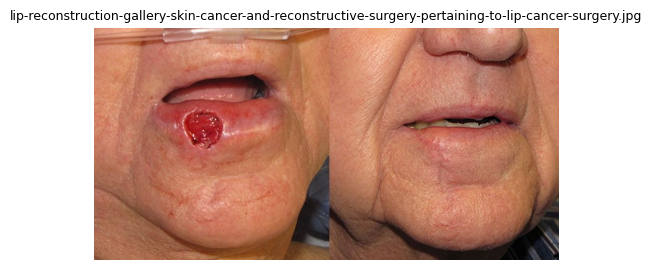

In [14]:
# Locate and display the image before dropping it
target = df[df["filename"].str.startswith("lip-reconstruction-gallery-skin-cancer-and-reconstructive-surgery-pertaining-to-lip-cancer-s")]
print(target[["filename", "class", "width", "height", "file_size_bytes"]])

img = Image.open(target["filepath"].values[0])
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(target["filename"].values[0], fontsize=9)
plt.axis("off")
plt.show()

In [15]:
# Drop the confirmed image from the dataframe
drop_filename = target["filename"].values[0]
df = df[df["filename"] != drop_filename].copy()

print(f"Dropped: {drop_filename}")
print(f"Remaining rows: {len(df)}")
print(df.groupby("class")["label"].count())

Dropped: lip-reconstruction-gallery-skin-cancer-and-reconstructive-surgery-pertaining-to-lip-cancer-surgery.jpg
Remaining rows: 106
class
cancer        63
non-cancer    43
Name: label, dtype: int64


In [16]:
# Final save: dedup done, conflict resolved, provenance flags and sample weights in place
df["likely_web_sourced"] = ~df["looks_camera_sourced"]
df["sample_weight"] = 1.0
df.loc[(df["class"] == "cancer") & df["likely_web_sourced"], "sample_weight"] = 0.5

df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(df)} rows to {OUTPUT_CSV}")
print(df.groupby(["class", "likely_web_sourced"])["sample_weight"].agg(["count", "mean"]))

Saved 106 rows to /kaggle/working/standardized_shivam_lips_tongue.csv
                               count  mean
class      likely_web_sourced             
cancer     False                   2   1.0
           True                   61   0.5
non-cancer False                  26   1.0
           True                   17   1.0
